Bit flip noise for ghz channel

global phase: π/2
     ┌─────────┐┌────┐┌─────────┐           ░ ┌───────┐┌────┐┌────────┐┌────┐»
q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■────■───░─┤ Rz(π) ├┤ √X ├┤ Rz(2π) ├┤ √X ├»
     └─────────┘└────┘└─────────┘┌─┴─┐  │   ░ └───────┘└────┘└────────┘└────┘»
q_1: ────────────────────────────┤ X ├──┼───░────────────────────────────────»
                                 └───┘┌─┴─┐ ░                                »
q_2: ─────────────────────────────────┤ X ├─░────────────────────────────────»
                                      └───┘ ░                                »
c: 3/════════════════════════════════════════════════════════════════════════»
                                                                             »
«     ┌────────┐ ░ ┌───┐ ░           ┌─────────┐┌────┐┌─────────┐ ░ ┌─┐      
«q_0: ┤ Rz(3π) ├─░─┤ I ├─░───■────■──┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─░─┤M├──────
«     └────────┘ ░ ├───┤ ░   │  ┌─┴─┐└─────────┘└────┘└─────────┘ ░ └╥┘┌─┐   
«q_1: ───────────░─┤ I ├─░───┼──┤ X ├

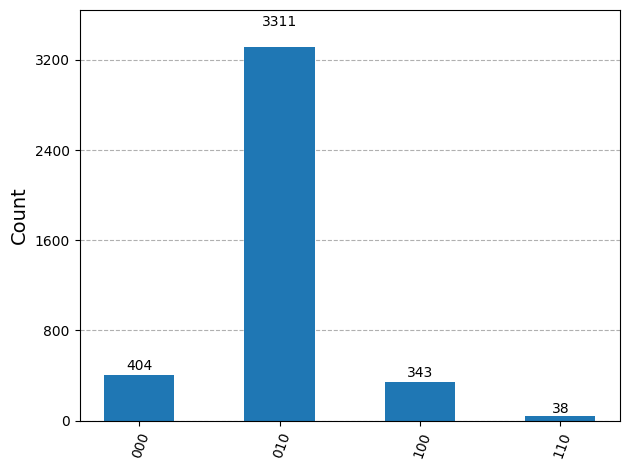

In [ ]:
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise import pauli_error

# ============================================================
# PARAMETERS
# ============================================================

shots = 4096

# Bit-flip probability
p = 0.9

# Alice's encoding
# First letter -> qubit 0
# Second letter -> qubit 1
message = "XI"
qc = QuantumCircuit(3,3)

# ============================================================
# GHZ STATE PREPARATION
# ============================================================

qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.barrier()

# ============================================================
# ALICE ENCODING
# ============================================================

alice = [0,1]

for op, qubit in zip(message, alice):

    if op == 'I':
        pass

    elif op == 'X':
        qc.x(qubit)

    elif op == 'Y':
        qc.y(qubit)

    elif op == 'Z':
        qc.z(qubit)

qc.barrier()

# ============================================================
# TRANSMISSION
# ============================================================

qc.id(0)
qc.id(1)

qc.barrier()

# ============================================================
# BOB DECODER
# ============================================================

qc.cx(0,2)
qc.cx(0,1)
qc.h(0)
qc.barrier()
qc.measure([0,1,2],[0,1,2])

# ============================================================
# BIT-FLIP NOISE MODEL
# ============================================================

bit_flip = pauli_error([
    ('X', p),
    ('I', 1-p)
])

noise_model = NoiseModel()

for gate in ['id']:
    noise_model.add_all_qubit_quantum_error(
        bit_flip,
        [gate]
    )

# ============================================================
# SIMULATOR
# ============================================================

backend = AerSimulator(noise_model=noise_model)

tqc = transpile(
    qc,
    backend,
    optimization_level=0
)

print(tqc)

result = backend.run(
    tqc,
    shots=shots
).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

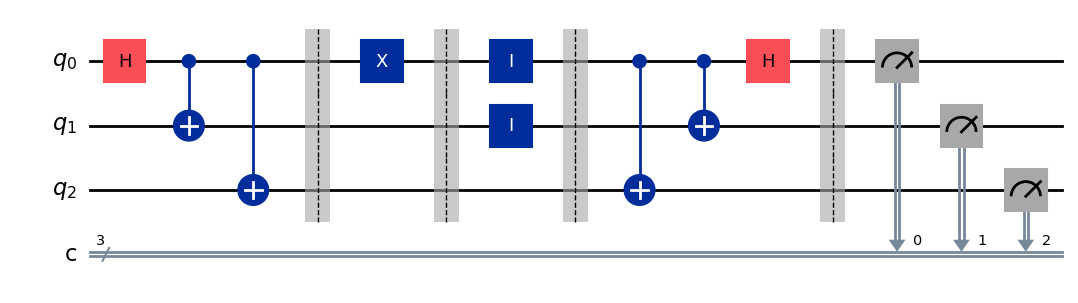

In [10]:
qc.draw(output="mpl")

<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ranga\AppData\Local\Temp\ipykernel_19360\2842344179.py:51: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Noise parameter $\eta_B$', fontsize=12)


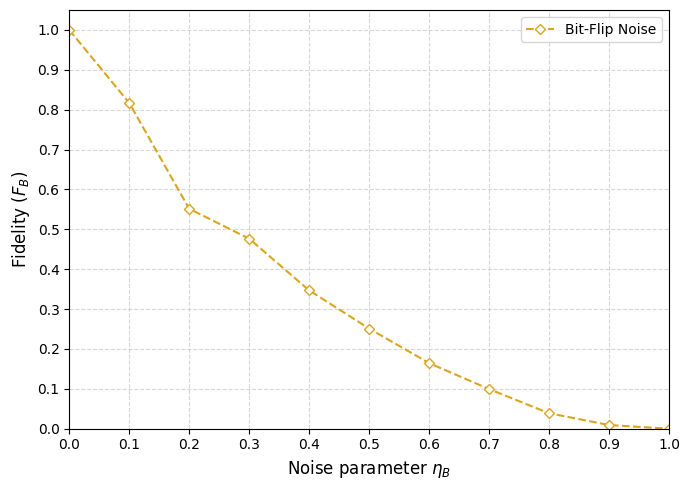

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# Data
# ================================

x = np.array([0.0, 0.1, 0.2, 0.3, 0.4,
              0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

y = np.array([1.0,
              0.81689,
              0.5515,
              0.4765,
              0.3469,
              0.2512,
              0.1645,
              0.09936,
              0.0388,
              0.00927,
              0.0])


plt.figure(figsize=(7,5))

plt.plot(
    x,
    y,
    color='goldenrod',
    linestyle='--',
    marker='D',
    markersize=5,
    markerfacecolor='white',
    linewidth=1.5,
    label='Bit-Flip Noise'
)

plt.xlim(0,1)
plt.ylim(0,1.05)

plt.xticks(np.arange(0,1.1,0.1))
plt.yticks(np.arange(0,1.1,0.1))

plt.xlabel('Noise parameter $\eta_B$', fontsize=12)
plt.ylabel('Fidelity ($F_B$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(frameon=True)

plt.tight_layout()

plt.show()